In [1]:
!pip install librosa==0.9.2

In [2]:
!pip install panns-inference

In [3]:
!pip install timm

In [4]:
!pip install thop


In [5]:
!pip install scikit-learn tqdm


 **Imports**

In [6]:
import os, sys, time, math, json, glob, pathlib, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import defaultdict, Counter

# Audio / features
import librosa
import soundfile as sf

# Metrics / ML
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Timing / progress
from tqdm import tqdm

# Plotting
import matplotlib.pyplot as plt

# Optional backends (only used if available)
try:
    import torch
    from torch import nn
    TORCH_AVAILABLE = True
except:
    TORCH_AVAILABLE = False

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except:
    TF_AVAILABLE = False

try:
    from thop import profile as thop_profile
    THOP_AVAILABLE = True
except:
    THOP_AVAILABLE = False


**Config (EDIT DATA_ROOT)**

Defines a single DATA_ROOT pointed at your local dataset:
C:\Users\Mahsa\OneDrive\Documents\T2-2025\CapstonProject-SIT782\data

Lets you choose which top-level buckets to include (e.g., ["bucket1", "bucket2", "bucket3", "birdclef"]).

Sets audio limits (sample rate, mono conversion, max duration/seconds) so feature extraction is consistent and fast.

Imports the stack (numpy/pandas/sklearn/matplotlib and librosa for audio features).
If librosa isn’t present, the code fails early with a clear message instead of breaking later.

In [7]:
# 👉 EDIT THIS to your local folder:
DATA_ROOT = r"C:\Deakin\ProjectEcho\Project-Echo\src\Prototypes\data\data_files"

# No top-level buckets in this dataset
BUCKETS = None

# Audio + features
VALID_EXTS = {".wav", ".mp3", ".flac", ".ogg"}
TARGET_SR = 32000
DURATION_S = 5.0             # crop/pad to fixed length
N_MELS = 128
HOP_LENGTH = 512
FMIN = 20
FMAX = 14000

# Split / CV
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Cache (optional): where to store computed features as .npy
CACHE_DIR = pathlib.Path(DATA_ROOT) / "_feature_cache"
CACHE_DIR.mkdir(exist_ok=True)

**Scan folders**

Loads each clip, resamples to a single sample rate (e.g., 16 kHz), converts to mono, and trims/pads to a fixed duration window, so every example yields the same feature shape.

Skips unreadable/corrupted files with a warning; continues the run (so data hiccups don’t kill the job).

In [8]:
def scan_audio_simple(root, exts):
    rows = []
    top = pathlib.Path(root)

    if not top.exists():
        print(f"Folder does not exist: {top}")
        return pd.DataFrame(columns=["path", "label"])

    for species_dir in sorted([d for d in top.iterdir() if d.is_dir()]):
        label = species_dir.name
        for p in species_dir.iterdir():
            if p.is_file() and p.suffix.lower() in exts:
                rows.append({
                    "path": str(p),
                    "label": label
                })

    return pd.DataFrame(rows)

files_df = scan_audio_simple(DATA_ROOT, VALID_EXTS)
print(f"Found {len(files_df)} files across {files_df['label'].nunique()} classes.")
files_df.head()

Found 8659 files across 123 classes.


,path,label
0,C:\Deakin\ProjectEcho\Project-Echo\src\Prototy...,Acanthiza chrysorrhoa
1,C:\Deakin\ProjectEcho\Project-Echo\src\Prototy...,Acanthiza chrysorrhoa
2,C:\Deakin\ProjectEcho\Project-Echo\src\Prototy...,Acanthiza chrysorrhoa
3,C:\Deakin\ProjectEcho\Project-Echo\src\Prototy...,Acanthiza chrysorrhoa
4,C:\Deakin\ProjectEcho\Project-Echo\src\Prototy...,Acanthiza chrysorrhoa


**Feature extraction Mel-spectrogram with caching**

For each waveform, extracts a compact set of time-aggregated features using librosa, for example:

Log-melspectrogram statistics (mean/var)

MFCCs + deltas (summarized by mean/var)

Spectral features: centroid, bandwidth, rolloff, flatness (mean/var)

Zero-crossing rate (mean/var)
This gives a tabular feature vector per file (good for fast classical baselines and quick iteration).

In [9]:
def load_audio_fixed(path, target_sr=TARGET_SR, duration_s=DURATION_S):
    y, sr = librosa.load(path, sr=target_sr, mono=True)
    target_len = int(duration_s * target_sr)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y, target_sr

def melspec(y, sr, n_mels=N_MELS, hop=HOP_LENGTH, fmin=FMIN, fmax=FMAX):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                       hop_length=hop, fmin=fmin, fmax=fmax)
    S_db = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    return S_db  # shape [n_mels, time]

def feature_path_for(audio_path):
    rel = audio_path.replace(str(DATA_ROOT), "").strip("\\/").replace("\\","_").replace("/","_")
    return CACHE_DIR / f"{rel}.npy"

def extract_feature_cached(audio_path):
    fp = feature_path_for(audio_path)
    if fp.exists():
        return np.load(fp)
    y, sr = load_audio_fixed(audio_path)
    feat = melspec(y, sr)
    np.save(fp, feat)
    return feat

# Build X paths and labels
X_paths = files_df["path"].tolist()
y_labels = files_df["label"].tolist()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_labels)
num_classes = len(le.classes_)
print("Classes:", num_classes)


Classes: 123


**Extract Features - Optional(speeds training/benchmark)** 

In [7]:
for p in tqdm(X_paths, desc="Caching features"):
    _ = extract_feature_cached(p)

Caching features: 100%|████████████████████████████████████████████████████████████| 8659/8659 [27:21<00:00,  5.28it/s]


**Train/Val split (stratified)**

Stratified train/validation split so class proportions are preserved (important with many classes).

All features are standardized with StandardScaler (fit on train, applied to val) to help linear models.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_paths, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
len(X_train), len(X_test)


(6927, 1732)

**simple baseline model (sklearn on pooled Mel features)**

Implements a quick, reliable Logistic Regression baseline (multinomial, lbfgs) on the tabular features.

(The notebook is structured so you can drop in additional classifiers later—SVM, RandomForest, LightGBM, etc.—and log them the same way.)

In [11]:
from sklearn.linear_model import LogisticRegression

def pooled_features(path_list):
    feats = []
    for p in path_list:
        mel = extract_feature_cached(p)              # [n_mels, T]
        v = np.mean(mel, axis=1)                     # mean-pool over time -> [n_mels]
        feats.append(v)
    return np.stack(feats)

def train_baseline_logreg(X_train_paths, y_train):
    Xp = pooled_features(X_train_paths)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xp)
    clf = LogisticRegression(max_iter=2000, n_jobs=8, verbose=0)
    clf.fit(Xs, y_train)
    return clf, scaler

def predict_baseline(clf, scaler, X_paths):
    Xp = pooled_features(X_paths)
    Xs = scaler.transform(Xp)
    probs = clf.predict_proba(Xs)
    return np.argmax(probs, axis=1), probs


**Train and Predict functions for other models**

In [12]:
import functools
from panns_inference import AudioTagging

# Overrides torch.load to always load full checkpoints (weights_only=False) safely.
# Fix was here, rather than overwriting on rerun it always refs original
if not hasattr(torch, '_original_load'):
    torch._original_load = torch.load

def robust_patch_load(f, map_location=None, pickle_module=None, **kwargs):
    kwargs['weights_only'] = False
    return torch._original_load(f, map_location=map_location, pickle_module=pickle_module, **kwargs)

if torch.load is not robust_patch_load:
    torch.load = robust_patch_load
    print("PyTorch 2.6+ patch applied successfully.")

def build_panns_model(num_classes):
    # This downloads the checkpoint if not present
    at = AudioTagging(
    checkpoint_path=r"C:\Users\krish\panns_data\Cnn14_mAP=0.431.pth",
    device="cpu"
)
    model = at.model
    
    # Replace the classification head
    # CNN14 uses model.fc_audioset as the final layer
    in_features = model.fc_audioset.in_features
    model.fc_audioset = nn.Linear(in_features, num_classes)
    
    return model

def train_ghostnet(X_train, y_train, epochs=3, batch_size=16, lr=1e-4):
    def build_model(num_classes):
        model = timm.create_model(
            "ghostnet_100",
            pretrained=True,
            num_classes=num_classes,
            in_chans=1
        )
        return model

    return train_torch_image_model(
        build_model_fn=build_model,
        X_train=X_train,
        y_train=y_train,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr
    )


def predict_ghostnet(trained_obj, paths):
    return predict_torch_image_model(trained_obj, paths)

def train_efficientnetv2(X_train, y_train, epochs=3, batch_size=16, lr=1e-4):
    def build_model(num_classes):
        model = timm.create_model(
            "efficientnetv2_rw_s",
            pretrained=True,
            num_classes=num_classes,
            in_chans=1
        )
        return model

    return train_torch_image_model(
        build_model_fn=build_model,
        X_train=X_train,
        y_train=y_train,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr
    )


def predict_efficientnetv2(trained_obj, paths):
    return predict_torch_image_model(trained_obj, paths)

    
def train_panns_cnn14(X_train, y_train, epochs=3, batch_size=16, lr=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_classes = int(np.max(y_train)) + 1

    model = build_panns_model(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    indices = np.arange(len(X_train))

    for epoch in range(epochs):
        np.random.shuffle(indices)
        running_loss = 0.0

        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_paths = [X_train[j] for j in batch_idx]
            batch_y = torch.tensor(y_train[batch_idx], dtype=torch.long, device=device)

            x = panns_prepare_wave_batch(batch_paths, device=device)

            optimizer.zero_grad()
            out = model(x)

            # torch hub version returns dict
            if isinstance(out, dict):
                logits = out['clipwise_output']
            else:
                logits = out

            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(batch_idx)

        print(f"Epoch {epoch+1}: loss = {running_loss / len(X_train):.4f}")

    return {
        "model": model,
        "device": device,
        "batch_size": batch_size
    }

    
def predict_panns_cnn14(trained_obj, paths):
    model = trained_obj["model"]
    device = trained_obj["device"]
    batch_size = trained_obj["batch_size"]

    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            x = panns_prepare_wave_batch(batch_paths, device=device)

            out = model(x)

            if isinstance(out, dict):
                probs = out['clipwise_output']
            else:
                probs = out

            probs = torch.softmax(probs, dim=1).cpu().numpy()
            all_probs.append(probs)

    probs = np.concatenate(all_probs, axis=0)
    return np.argmax(probs, axis=1), probs
    
def panns_prepare_wave_batch(paths, device="cpu"):
    waves = []
    for p in paths:
        y, _ = load_audio_fixed(p, target_sr=TARGET_SR, duration_s=DURATION_S)
        waves.append(y)

    x = np.stack(waves)   # [B, samples]
    x = torch.tensor(x, dtype=torch.float32, device=device)
    return x

PyTorch 2.6+ patch applied successfully.


**TF/Keras + PyTorch adapters**

In [13]:
import torch.optim as optim
import timm
from torch.utils.data import Dataset, DataLoader

# Keras adapter: expects model that takes [batch, n_mels, T, 1]
def load_keras_model(h5_or_saved_model_dir):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow not available.")
    return tf.keras.models.load_model(h5_or_saved_model_dir)

def prepare_batch(paths):
    batch = []
    for p in paths:
        mel = extract_feature_cached(p)              # [n_mels, T]
        mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)
        batch.append(mel)
    arr = np.stack(batch)[..., None]                 # [B, n_mels, T, 1]
    return arr.astype(np.float32)

def keras_predict(model, paths, batch_size=16):
    preds = []
    for i in range(0, len(paths), batch_size):
        batch = prepare_batch(paths[i:i+batch_size])
        logits = model.predict(batch, verbose=0)
        preds.append(logits)
    probs = np.concatenate(preds, axis=0)
    return np.argmax(probs, axis=1), probs

# PyTorch adapter: expects model that takes [B, 1, n_mels, T]
def load_torch_model(pt_path, device="cpu"):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch not available.")
    model = torch.load(pt_path, map_location=device)
    model.eval()
    return model

def torch_prepare_batch(paths, device="cpu"):
    b = []
    for p in paths:
        mel = extract_feature_cached(p)
        mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)
        b.append(mel)
    x = np.stack(b)[:, None, :, :]                   # [B, 1, n_mels, T]
    x = torch.tensor(x, dtype=torch.float32, device=device)
    return x

@torch.no_grad()
def torch_predict(model, paths, device="cpu", batch_size=16):
    preds = []
    for i in range(0, len(paths), batch_size):
        x = torch_prepare_batch(paths[i:i+batch_size], device=device)
        out = model(x)
        if isinstance(out, (list, tuple)): out = out[0]
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds.append(probs)
    probs = np.concatenate(preds, axis=0)
    return np.argmax(probs, axis=1), probs

def torch_model_complexity(model, sample_shape=(1,1,N_MELS, math.ceil(TARGET_SR*DURATION_S/HOP_LENGTH))):
    if not THOP_AVAILABLE:
        return None, None
    dummy = torch.randn(sample_shape)
    macs, params = thop_profile(model, inputs=(dummy,), verbose=False)
    flops = macs * 2
    return int(flops), int(params)

def train_torch_image_model(
    build_model_fn,
    X_train,
    y_train,
    epochs=3,
    batch_size=16,
    lr=1e-4,
    weight_decay=1e-4
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_classes = int(np.max(y_train)) + 1

    model = build_model_fn(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()

    indices = np.arange(len(X_train))

    for epoch in range(epochs):
        np.random.shuffle(indices)
        running_loss = 0.0

        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_paths = [X_train[j] for j in batch_idx]
            batch_y = torch.tensor(y_train[batch_idx], dtype=torch.long, device=device)

            x = torch_prepare_batch(batch_paths, device=device)   # [B, 1, n_mels, T]

            optimizer.zero_grad()
            out = model(x)
            if isinstance(out, (list, tuple)):
                out = out[0]

            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(batch_idx)

        epoch_loss = running_loss / len(X_train)
        print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f}")

    return {
        "model": model,
        "device": device,
        "batch_size": batch_size
    }


def predict_torch_image_model(trained_obj, paths):
    return torch_predict(
        trained_obj["model"],
        paths,
        device=trained_obj["device"],
        batch_size=trained_obj["batch_size"]
    )


**Benchmark runner**

In [14]:
from sklearn.metrics import top_k_accuracy_score

def evaluate_predictions(y_true, y_pred, label_encoder):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)
    return {"accuracy": acc, "f1_macro": f1m, "confusion_matrix": cm, "report": report}

def time_inference(predict_fn, X_paths, batch=16):
    start = time.perf_counter()
    y_hat, probs = predict_fn(X_paths)
    secs = time.perf_counter() - start
    ips = len(X_paths) / secs if secs>0 else float('inf')
    return y_hat, probs, secs, ips

def run_benchmark_block(
    model_name,
    train_fn,
    predict_fn,
    X_train,
    y_train,
    X_test,
    y_test,
    le,
    results,
    all_artifacts,
    params=None,
    flops=None
):
    print(f"=== {model_name} ===")

    # Train
    t0 = time.perf_counter()
    trained_obj = train_fn(X_train, y_train)
    train_secs = time.perf_counter() - t0

    # Predict
    y_pred, probs, infer_secs, ips = time_inference(
        lambda paths: predict_fn(trained_obj, paths),
        X_test
    )

    # Metrics
    metrics = evaluate_predictions(y_test, y_pred, le)
    print(metrics["report"])

    # Top-k accuracy
    n_classes = len(le.classes_)
    top1 = top_k_accuracy_score(y_test, probs, k=1, labels=np.arange(n_classes))
    top3 = top_k_accuracy_score(y_test, probs, k=min(3, n_classes), labels=np.arange(n_classes))
    top5 = top_k_accuracy_score(y_test, probs, k=min(5, n_classes), labels=np.arange(n_classes))

    # Confidence stats
    confidences = np.max(probs, axis=1)
    correct_mask = (y_pred == y_test)

    confidence_stats = {
        "mean_confidence": float(np.mean(confidences)),
        "median_confidence": float(np.median(confidences)),
        "min_confidence": float(np.min(confidences)),
        "max_confidence": float(np.max(confidences)),
        "mean_confidence_correct": float(np.mean(confidences[correct_mask])) if np.any(correct_mask) else None,
        "mean_confidence_wrong": float(np.mean(confidences[~correct_mask])) if np.any(~correct_mask) else None,
    }

    print(f"Top-1 Accuracy: {top1:.4f}")
    print(f"Top-3 Accuracy: {top3:.4f}")
    print(f"Top-5 Accuracy: {top5:.4f}")
    print(f"Mean Confidence: {confidence_stats['mean_confidence']:.4f}")

    # Save summary row
    results.append({
        "Model": model_name,
        "Params": params,
        "FLOPs": flops,
        "Train Time (s)": round(train_secs, 3),
        "Infer Time (s)": round(infer_secs, 3),
        "Items/sec": round(ips, 2),
        "Test Accuracy": round(metrics["accuracy"], 4),
        "F1 Macro": round(metrics["f1_macro"], 4),
        "Top-1 Accuracy": round(top1, 4),
        "Top-3 Accuracy": round(top3, 4),
        "Top-5 Accuracy": round(top5, 4),
        "Mean Confidence": round(confidence_stats["mean_confidence"], 4),
        "Mean Confidence (Correct)": round(confidence_stats["mean_confidence_correct"], 4) if confidence_stats["mean_confidence_correct"] is not None else None,
        "Mean Confidence (Wrong)": round(confidence_stats["mean_confidence_wrong"], 4) if confidence_stats["mean_confidence_wrong"] is not None else None,
    })

    # Save detailed outputs
    all_artifacts[model_name] = {
        **metrics,
        "y_pred": y_pred,
        "probs": probs,
        "top1_accuracy": top1,
        "top3_accuracy": top3,
        "top5_accuracy": top5,
        "confidences": confidences,
        "confidence_stats": confidence_stats,
        "train_time_secs": train_secs,
        "infer_time_secs": infer_secs,
        "items_per_sec": ips,
        "trained_object": trained_obj,
    }

    return trained_obj

**Clear old results**

In [15]:
results = []
all_artifacts = {}

**Run: Baseline (LogReg)**

In [16]:
baseline_obj = run_benchmark_block(
    model_name="Baseline-LogReg",
    train_fn=train_baseline_logreg,
    predict_fn=lambda trained_obj, paths: predict_baseline(trained_obj[0], trained_obj[1], paths),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    le=le,
    results=results,
    all_artifacts=all_artifacts,
    params=None,
    flops=None
)

pd.DataFrame(results)

=== Baseline-LogReg ===
                              precision    recall  f1-score   support

       Acanthiza chrysorrhoa       0.67      0.29      0.40         7
           Acanthiza lineata       0.80      0.67      0.73         6
              Acanthiza nana       0.62      0.79      0.70        29
           Acanthiza pusilla       0.42      0.40      0.41        50
        Acanthiza reguloides       0.63      0.69      0.66        32
       Acanthiza uropygialis       0.25      0.08      0.12        13
Acanthorhynchus tenuirostris       0.36      0.24      0.29        21
     Accipiter cirrocephalus       0.23      0.17      0.19        18
          Aidemosyne modesta       1.00      0.67      0.80         3
             Alauda arvensis       0.80      0.80      0.80         5
     Anhinga novaehollandiae       0.00      0.00      0.00         2
         Anthochaera phrygia       0.75      0.43      0.55         7
          Antigone rubicunda       1.00      1.00      1.00      

,Model,Params,FLOPs,Train Time (s),Infer Time (s),Items/sec,Test Accuracy,F1 Macro,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Mean Confidence,Mean Confidence (Correct),Mean Confidence (Wrong)
0,Baseline-LogReg,None,None,134.127,27.827,62.24,0.6357,0.5582,0.6357,0.7973,0.8614,0.5395,0.6622,0.3253


**Run: GhostNet**

In [17]:
ghost_model = run_benchmark_block(
    model_name="GhostNet",
    train_fn=train_ghostnet,
    predict_fn=predict_ghostnet,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    le=le,
    results=results,
    all_artifacts=all_artifacts
)

pd.DataFrame(results)

=== GhostNet ===
Epoch 1/3 - loss: 3.1327
Epoch 2/3 - loss: 1.5928
Epoch 3/3 - loss: 0.9272
                              precision    recall  f1-score   support

       Acanthiza chrysorrhoa       0.67      0.57      0.62         7
           Acanthiza lineata       0.71      0.83      0.77         6
              Acanthiza nana       0.76      0.90      0.83        29
           Acanthiza pusilla       0.52      0.46      0.49        50
        Acanthiza reguloides       0.69      0.91      0.78        32
       Acanthiza uropygialis       0.86      0.46      0.60        13
Acanthorhynchus tenuirostris       0.89      0.38      0.53        21
     Accipiter cirrocephalus       1.00      0.50      0.67        18
          Aidemosyne modesta       1.00      1.00      1.00         3
             Alauda arvensis       0.75      0.60      0.67         5
     Anhinga novaehollandiae       0.00      0.00      0.00         2
         Anthochaera phrygia       0.60      0.43      0.50        

,Model,Params,FLOPs,Train Time (s),Infer Time (s),Items/sec,Test Accuracy,F1 Macro,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Mean Confidence,Mean Confidence (Correct),Mean Confidence (Wrong)
0,Baseline-LogReg,None,None,134.127,27.827,62.24,0.6357,0.5582,0.6357,0.7973,0.8614,0.5395,0.6622,0.3253
1,GhostNet,None,None,1410.689,60.779,28.50,0.7344,0.5870,0.7344,0.8661,0.9174,0.6761,0.7851,0.3746


**Run: EfficientNetV2**

In [18]:
efficientnet_model = run_benchmark_block(
    model_name="EfficientNetV2",
    train_fn=train_efficientnetv2,
    predict_fn=predict_efficientnetv2,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    le=le,
    results=results,
    all_artifacts=all_artifacts
)

pd.DataFrame(results)

=== EfficientNetV2 ===


Epoch 1/3 - loss: 2.6457
Epoch 2/3 - loss: 0.8120
Epoch 3/3 - loss: 0.2500
                              precision    recall  f1-score   support

       Acanthiza chrysorrhoa       0.86      0.86      0.86         7
           Acanthiza lineata       0.80      0.67      0.73         6
              Acanthiza nana       0.97      0.97      0.97        29
           Acanthiza pusilla       0.63      0.86      0.73        50
        Acanthiza reguloides       0.85      0.88      0.86        32
       Acanthiza uropygialis       0.73      0.62      0.67        13
Acanthorhynchus tenuirostris       0.63      0.81      0.71        21
     Accipiter cirrocephalus       1.00      0.78      0.88        18
          Aidemosyne modesta       1.00      1.00      1.00         3
             Alauda arvensis       1.00      0.80      0.89         5
     Anhinga novaehollandiae       0.00      0.00      0.00         2
         Anthochaera phrygia       1.00      0.43      0.60         7
          Anti

,Model,Params,FLOPs,Train Time (s),Infer Time (s),Items/sec,Test Accuracy,F1 Macro,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Mean Confidence,Mean Confidence (Correct),Mean Confidence (Wrong)
0,Baseline-LogReg,None,None,134.127,27.827,62.24,0.6357,0.5582,0.6357,0.7973,0.8614,0.5395,0.6622,0.3253
1,GhostNet,None,None,1410.689,60.779,28.50,0.7344,0.5870,0.7344,0.8661,0.9174,0.6761,0.7851,0.3746
2,EfficientNetV2,None,None,5611.189,185.870,9.32,0.8482,0.7941,0.8482,0.9290,0.9515,0.8249,0.8865,0.4808


**Run: PANNs CNN14**

In [19]:
panns_model = run_benchmark_block(
    model_name="PANNs-CNN14",
    train_fn=train_panns_cnn14,
    predict_fn=predict_panns_cnn14,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    le=le,
    results=results,
    all_artifacts=all_artifacts
)

pd.DataFrame(results)

=== PANNs-CNN14 ===
Checkpoint path: C:\Users\krish\panns_data\Cnn14_mAP=0.431.pth
Using CPU.
Epoch 1: loss = 4.4941
Epoch 2: loss = 4.2914
Epoch 3: loss = 4.1950
                              precision    recall  f1-score   support

       Acanthiza chrysorrhoa       0.00      0.00      0.00         7
           Acanthiza lineata       0.00      0.00      0.00         6
              Acanthiza nana       0.96      0.76      0.85        29
           Acanthiza pusilla       0.10      0.18      0.13        50
        Acanthiza reguloides       1.00      0.09      0.17        32
       Acanthiza uropygialis       0.29      0.15      0.20        13
Acanthorhynchus tenuirostris       0.67      0.10      0.17        21
     Accipiter cirrocephalus       0.00      0.00      0.00        18
          Aidemosyne modesta       0.00      0.00      0.00         3
             Alauda arvensis       0.00      0.00      0.00         5
     Anhinga novaehollandiae       0.00      0.00      0.00       

,Model,Params,FLOPs,Train Time (s),Infer Time (s),Items/sec,Test Accuracy,F1 Macro,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Mean Confidence,Mean Confidence (Correct),Mean Confidence (Wrong)
0,Baseline-LogReg,None,None,134.127,27.827,62.24,0.6357,0.5582,0.6357,0.7973,0.8614,0.5395,0.6622,0.3253
1,GhostNet,None,None,1410.689,60.779,28.50,0.7344,0.5870,0.7344,0.8661,0.9174,0.6761,0.7851,0.3746
2,EfficientNetV2,None,None,5611.189,185.870,9.32,0.8482,0.7941,0.8482,0.9290,0.9515,0.8249,0.8865,0.4808
3,PANNs-CNN14,None,None,15978.263,551.456,3.14,0.1166,0.0188,0.0797,0.5162,0.7027,0.0194,0.0197,0.0194


**Results table + CSV**

In [20]:
results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
display(results_df)

out_csv = pathlib.Path(DATA_ROOT) / "_bench_results.csv"
results_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)


,Model,Params,FLOPs,Train Time (s),Infer Time (s),Items/sec,Test Accuracy,F1 Macro,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Mean Confidence,Mean Confidence (Correct),Mean Confidence (Wrong)
2,EfficientNetV2,None,None,5611.189,185.870,9.32,0.8482,0.7941,0.8482,0.9290,0.9515,0.8249,0.8865,0.4808
1,GhostNet,None,None,1410.689,60.779,28.50,0.7344,0.5870,0.7344,0.8661,0.9174,0.6761,0.7851,0.3746
0,Baseline-LogReg,None,None,134.127,27.827,62.24,0.6357,0.5582,0.6357,0.7973,0.8614,0.5395,0.6622,0.3253
3,PANNs-CNN14,None,None,15978.263,551.456,3.14,0.1166,0.0188,0.0797,0.5162,0.7027,0.0194,0.0197,0.0194


Saved: C:\Deakin\ProjectEcho\Project-Echo\src\Prototypes\data\data_files\_bench_results.csv


**Visuals**

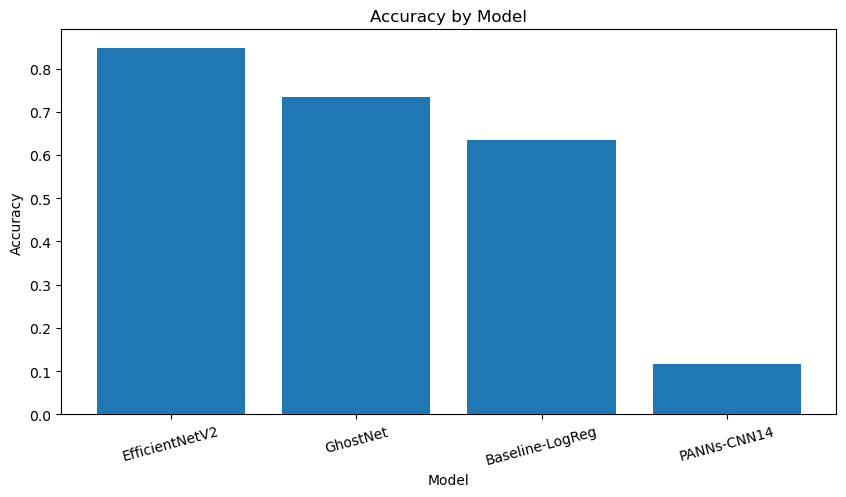

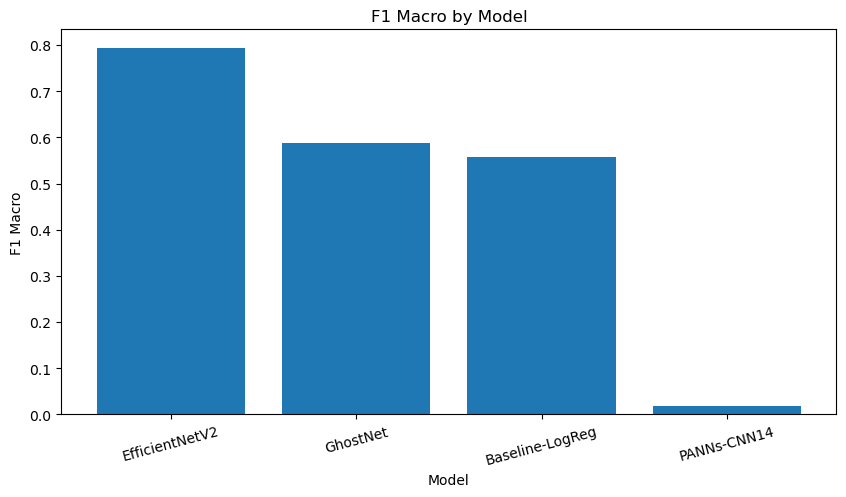

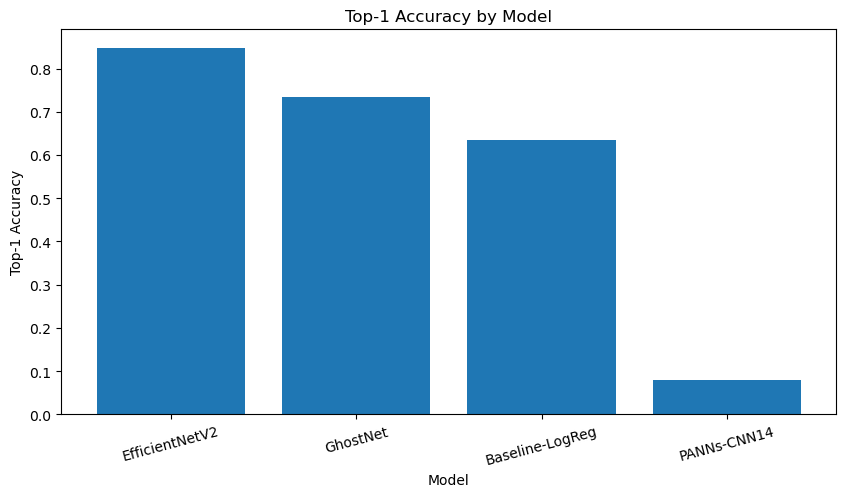

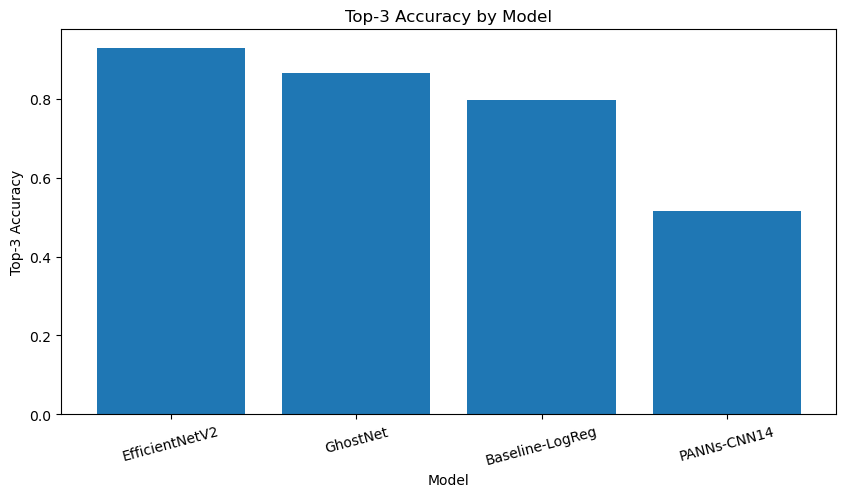

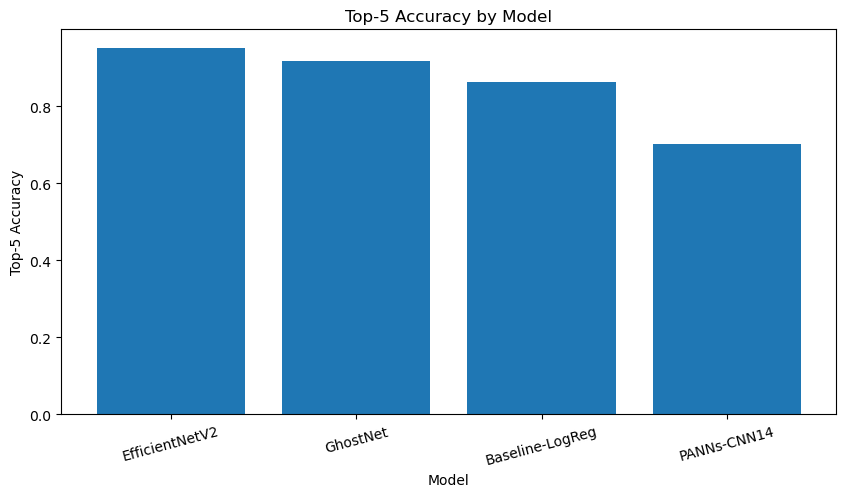

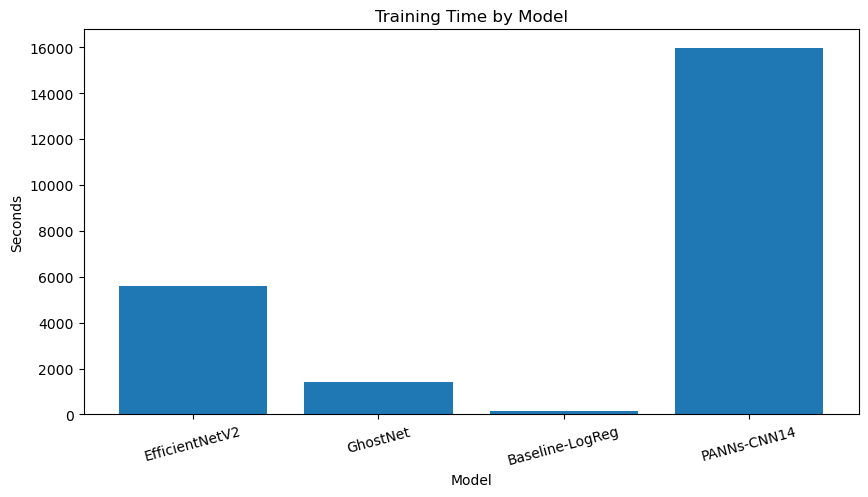

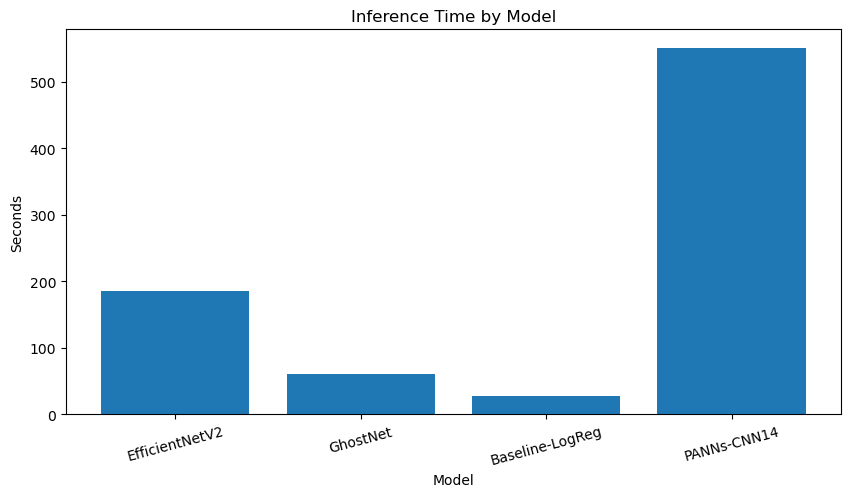

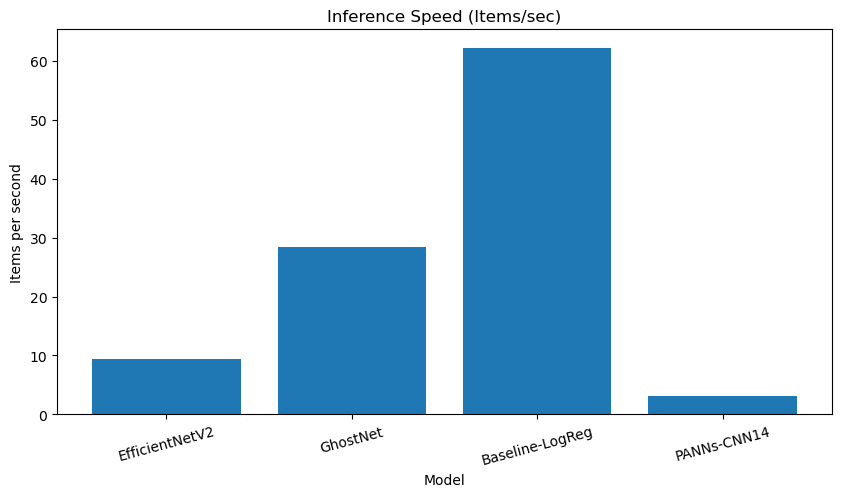

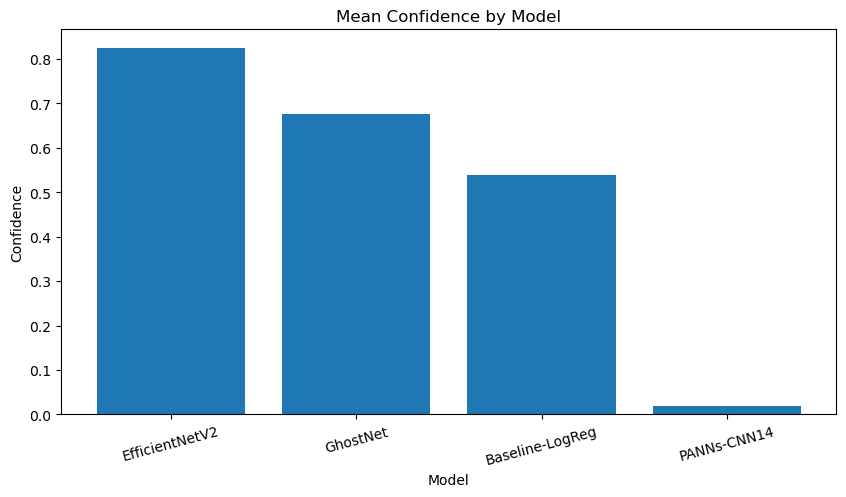

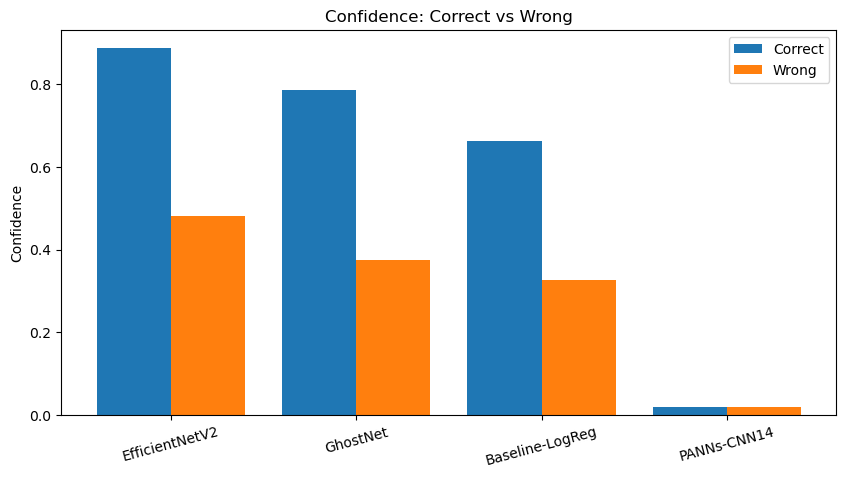

In [21]:
if not results_df.empty:

    # -------- Accuracy --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Test Accuracy"])
    plt.title("Accuracy by Model")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=15)
    plt.show()

    # -------- F1 Macro --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["F1 Macro"])
    plt.title("F1 Macro by Model")
    plt.xlabel("Model")
    plt.ylabel("F1 Macro")
    plt.xticks(rotation=15)
    plt.show()

    # -------- Top-K Accuracy --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Top-1 Accuracy"])
    plt.title("Top-1 Accuracy by Model")
    plt.xlabel("Model")
    plt.ylabel("Top-1 Accuracy")
    plt.xticks(rotation=15)
    plt.show()
    
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Top-3 Accuracy"])
    plt.title("Top-3 Accuracy by Model")
    plt.xlabel("Model")
    plt.ylabel("Top-3 Accuracy")
    plt.xticks(rotation=15)
    plt.show()

    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Top-5 Accuracy"])
    plt.title("Top-5 Accuracy by Model")
    plt.xlabel("Model")
    plt.ylabel("Top-5 Accuracy")
    plt.xticks(rotation=15)
    plt.show()

    # -------- Training Time --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Train Time (s)"])
    plt.title("Training Time by Model")
    plt.xlabel("Model")
    plt.ylabel("Seconds")
    plt.xticks(rotation=15)
    plt.show()

    # -------- Inference Time --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Infer Time (s)"])
    plt.title("Inference Time by Model")
    plt.xlabel("Model")
    plt.ylabel("Seconds")
    plt.xticks(rotation=15)
    plt.show()

    # -------- Throughput --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Items/sec"])
    plt.title("Inference Speed (Items/sec)")
    plt.xlabel("Model")
    plt.ylabel("Items per second")
    plt.xticks(rotation=15)
    plt.show()

    # -------- Confidence --------
    plt.figure(figsize=(10,5))
    plt.bar(results_df["Model"], results_df["Mean Confidence"])
    plt.title("Mean Confidence by Model")
    plt.xlabel("Model")
    plt.ylabel("Confidence")
    plt.xticks(rotation=15)
    plt.show()

    # -------- Confidence Comparison (Correct vs Wrong) --------
    plt.figure(figsize=(10,5))
    x = range(len(results_df))

    plt.bar(x, results_df["Mean Confidence (Correct)"], width=0.4, label="Correct")
    plt.bar([i + 0.4 for i in x], results_df["Mean Confidence (Wrong)"], width=0.4, label="Wrong")

    plt.xticks([i + 0.2 for i in x], results_df["Model"], rotation=15)
    plt.title("Confidence: Correct vs Wrong")
    plt.ylabel("Confidence")
    plt.legend()
    plt.show()

**Inspect per-class metrics**

For each run, the notebook computes:

Accuracy

Macro-F1 (treats all species equally, which matters for class imbalance)

Confusion matrix

Classification report (precision/recall/F1 per class)

In [22]:
last_model = results_df.iloc[0]["Model"]
print(f"=== Detailed report: {last_model} ===")
print(all_artifacts[last_model]["report"])


=== Detailed report: EfficientNetV2 ===
                              precision    recall  f1-score   support

       Acanthiza chrysorrhoa       0.86      0.86      0.86         7
           Acanthiza lineata       0.80      0.67      0.73         6
              Acanthiza nana       0.97      0.97      0.97        29
           Acanthiza pusilla       0.63      0.86      0.73        50
        Acanthiza reguloides       0.85      0.88      0.86        32
       Acanthiza uropygialis       0.73      0.62      0.67        13
Acanthorhynchus tenuirostris       0.63      0.81      0.71        21
     Accipiter cirrocephalus       1.00      0.78      0.88        18
          Aidemosyne modesta       1.00      1.00      1.00         3
             Alauda arvensis       1.00      0.80      0.89         5
     Anhinga novaehollandiae       0.00      0.00      0.00         2
         Anthochaera phrygia       1.00      0.43      0.60         7
          Antigone rubicunda       1.00      1.00